# 02 — Detection models and Bayesian update

This notebook explains how a single mission modifies the posterior.

A negative search outcome ($s_t = 0$) does **not** mean the aircraft is absent from the searched region. It means that, *if* it was there, it was not detected — a probabilistic event whose probability depends on three factors:

1. The search effort applied.
2. The depth of the cell.
3. The roughness of the cell.

The notebook walks through the four detector families, the per-mission likelihood, and a worked update on a real rectangle.

In [4]:
%load_ext autoreload
%autoreload 2

import warnings; warnings.filterwarnings('ignore')
import sys, os
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from update_version.simulator.grid import load_grid
from update_version.simulator.environment import SearchEnvironment
from update_version.simulator.true_detection import TrueDetector
from update_version.modeling.features import (
    ACCIDENT_POINT, V_PLANE, V_WIND, V_DRIFT, ALPHA_WIND,
    expected_landing, trajectory_axes, cell_distances, evaluate_pi,
)
from update_version.modeling.priors_logistic import PRIORS
from update_version.modeling.detection import DETECTORS
from update_version.strategies.next_mission import (
    hdr_mask, propose_via_hdr_topk, propose_drift_tail_rescue,
    progressive_drift_prior, progressive_scenario_prior,
    apply_drift_tail_escape, apply_progressive_scenario_escape,
    propose_progressive_scenario_search,
)

grid = load_grid('../data/grid_dataset.csv')
BUDGET_CAP = 530


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Detection probability

For a cell $j$ and effort $e$, every detector model returns
$$
\rho_j(e) = P(\text{detect} \mid Z = j,\; j \in R_t,\; e_t = e).
$$

If the cell is outside the searched rectangle the effective detection probability is zero; if it is inside, the effective probability equals $\rho_j$.

The four implemented families are:

1. **Saturating exponential** — increases with effort and saturates near 1.
2. **Independent passes** — treats effort as a number of independent inspections.
3. **Logistic GLM** — a regression-style model on depth, roughness and effort.
4. **Multiplicative with threshold** — heavily penalises very difficult cells.

Heatmaps for each model at $e \in \{1, 2, 3\}$:

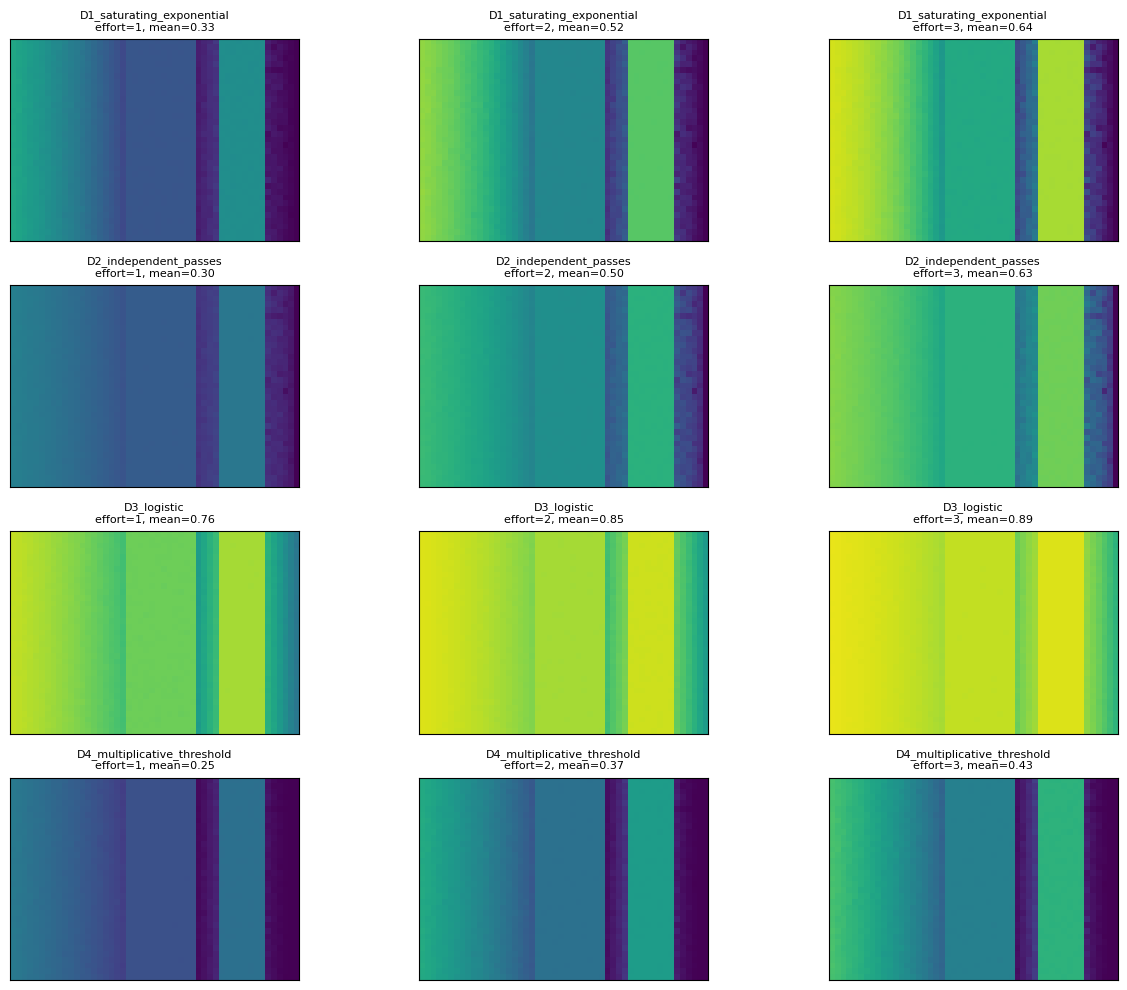

In [5]:
efforts = [1, 2, 3]
fig, axes = plt.subplots(len(DETECTORS), len(efforts), figsize=(13, 10))
for r, (name, det) in enumerate(DETECTORS.items()):
    for c, e in enumerate(efforts):
        rho = det.rho(grid.depth, grid.roughness, e)
        ax = axes[r, c]
        ax.imshow(grid.reshape_2d(rho), origin='lower', extent=[0, grid.Nx, 0, grid.Ny], cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'{name}\neffort={e}, mean={rho.mean():.2f}', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

## Mission likelihood

Let $R_t$ denote the rectangle searched in mission $t$. Define
$$
q_{t,j} = \rho_j(e_t)\,\mathbb{1}(j \in R_t).
$$

If the aircraft is detected ($s_t = 1$), the per-cell likelihood is
$$
L_j = q_{t,j}.
$$

If it is not detected ($s_t = 0$), the per-cell likelihood is
$$
L_j = 1 - q_{t,j}.
$$

The direct cell-level Bayesian update is
$$
P(Z = j \mid s_{1:t}) \propto P(Z = j \mid s_{1:t-1})\,L_j^{T}.
$$

The exponent $T$ is an **update temperature**. When $T > 1$, a failed mission carried out with a high detection probability penalises the inspected region more aggressively — a useful knob when the detector model is trusted.

In [ ]:
def cell_update(posterior, rect, effort, s_t, detector, temperature=1.5):
    x0, x1, y0, y1 = rect
    rho = detector.rho(grid.depth, grid.roughness, effort)
    covered = grid.coverage_mask(x0, x1, y0, y1)
    q = np.where(covered, rho, 0.0)
    q = np.clip(q, 1e-12, 1 - 1e-12)
    L = (q if s_t == 1 else 1 - q) ** temperature
    post = posterior * L
    post = post / post.sum()
    return q, L, post, covered

prior = PRIORS['P12_impact_balanced'].prior_predictive_pi(grid.x, grid.y, n_samples=800, seed=0)
rect = (9.5, 13.5, 12.5, 16.5)
q, L, post, covered = cell_update(prior, rect, effort=2, s_t=0,
                                    detector=DETECTORS['D1_saturating_exponential'])
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
plots = [
    (prior, 'Prior  P(Z)',                       'magma'),
    (q,     'q_j: effective detection prob.',   'viridis'),
    (L,     'Likelihood  if  s_t = 0',           'cividis'),
    (post,  'Posterior  after  failure',         'magma'),
]
for ax, (values, title, cmap) in zip(axes, plots):
    ax.imshow(grid.reshape_2d(values), origin='lower',
                extent=[0, grid.Nx, 0, grid.Ny], cmap=cmap)
    ax.add_patch(plt.Rectangle((rect[0], rect[2]),
                                rect[1] - rect[0], rect[3] - rect[2],
                                edgecolor='white', facecolor='none', lw=2))
    ax.set_title(title, fontsize=10)
plt.suptitle('Worked example: prior → effective detection map → likelihood → posterior',
              y=1.02, fontsize=12)
plt.tight_layout(); plt.show()